In [2]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy

Pour toute la suite, on se place sur un certain espace probabilisé $(\Omega, \mathcal F, \mathbb P)$. 

# 1) Les bases 

Dans cette section, on voit quelques outils de base sur Python qui peuvent s'avérer pratiques (voire essentiels) pour la modé.

## 1.1) Gérer des arrays 

Tout d'abord, voilà quelques outils de base pour manier des arrays numpy. Certains des "gadgets" présentés ici ne sont pas indispensables (il y a même sûrement des programmes dans la suite qui ne les utilisent pas alors qu'ils pourraient), mais ça peut toujours être pratique pour gagner du temps ! 

In [5]:
a=np.zeros(5) #vecteur de taille 5 rempli de 0 
b=np.ones(5) #vecteur de taille 5 rempli de 1 
#On peut faire la même chose avec des matrices: 
A,B=np.zeros((5,5)),np.ones((5,5))
#Matrice identité: 
C=np.eye(5) 
#tableau des nombres entre 1 et n avec np.arange: 
D=np.arange(1,26) 
#Pour redimensionner un tableau: 
D=D.reshape((5,5))
print(D)
#Pour construire une matrice diagonale à partir d'un vecteur diagonal donné: 
E=np.diag(np.arange(1,6))
# Et puis les commandes pour accéder aux différents éléments d'une matrice avec quelques exemples sur la matrice D: 
print(D[0,:]) #sa première ligne
print(D[:2,:]) #ses deux premières lignes
print(D[:,0]) #sa première colonne
print(D[:,-1]) #sa dernière colonne
print(D[-1,-1]) #l'élement en bas à droite
print(D[:2,:2]) #le deuxième mineur principal 
# Enfin, ça peut être utile, la commande pour inverser l'ordre d'un vecteur: 
v=np.linspace(1,5,25) #np.linspace(start,stop,num), donne un tableau avec num nombres entre start et stop (pratique)
w=v[::-1]
print(v)
print(w)
# et la commande pour trouver les indices d'un tableau qui ont une valeur qu'on se fixe: 
x=stats.randint.rvs(low=0, high=9, size=50)
print(x)
y=np.where(x==0)[0] #renvoie un array avec la liste d'indices 
print(y)
F=D.dot(E) # fait le produit des matrices D et E
print(F)
G=D**2 # met tous les coefficients au carré
print(G)
H=np.linalg.matrix_power(D,2) 
print(H)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]
[1 2 3 4 5]
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]
[ 1  6 11 16 21]
[ 5 10 15 20 25]
25
[[1 2]
 [6 7]]
[1.         1.16666667 1.33333333 1.5        1.66666667 1.83333333
 2.         2.16666667 2.33333333 2.5        2.66666667 2.83333333
 3.         3.16666667 3.33333333 3.5        3.66666667 3.83333333
 4.         4.16666667 4.33333333 4.5        4.66666667 4.83333333
 5.        ]
[5.         4.83333333 4.66666667 4.5        4.33333333 4.16666667
 4.         3.83333333 3.66666667 3.5        3.33333333 3.16666667
 3.         2.83333333 2.66666667 2.5        2.33333333 2.16666667
 2.         1.83333333 1.66666667 1.5        1.33333333 1.16666667
 1.        ]
[4 8 2 7 7 6 7 1 3 1 7 5 0 4 7 8 8 3 0 0 5 3 0 3 0 3 4 0 4 7 1 7 6 8 6 2 3
 5 1 0 4 1 1 1 7 8 8 7 1 6]
[12 18 19 22 24 27 39]
[[  1   4   9  16  25]
 [  6  14  24  36  50]
 [ 11  24  39  56  75]
 [ 16  34  54  76 100]
 [ 21  44  69  96 125]]
[[  

## 1.2) Tracer des graphiques 

Maintenant, quelque chose d'ESSENTIEL pour les simulations de modé: les graphiques. Déjà, un premier basique : savoir tracer une simple courbe, mais BIEN LEGENDEE: (pour des tracés en 3D, cf TP2 mais ce n'est pas essentiel selon moi) 

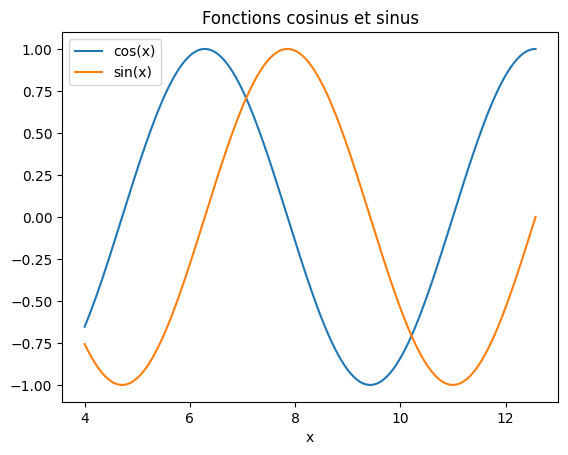

In [7]:
X=np.linspace(4,4*pi,150)
Y=np.cos(X)
Z=np.sin(X)
plt.xlabel('x')
plt.plot(X,Y,label='cos(x)')
plt.plot(X,Z,label='sin(x)')
plt.title('Fonctions cosinus et sinus')
plt.legend()
plt.show()

Ensuite, TRES important, savoir tracer un histogramme (souvent à comparer avec une densité de référence): 

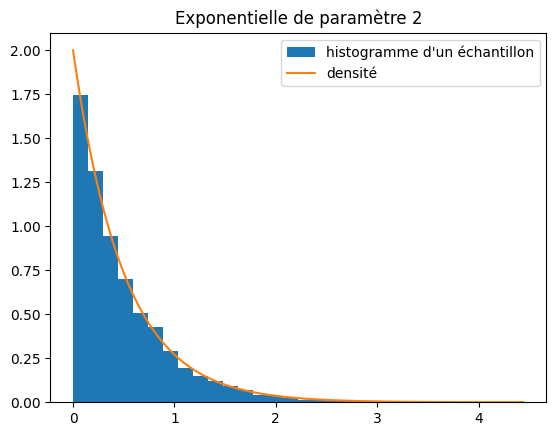

In [9]:
X=stats.expon.rvs(scale=0.5, size=10000)
plt.hist(X,bins=30, density=True, label="histogramme d'un échantillon")
T=np.arange(0,max(X), 0.01)
plt.plot(T,stats.expon.pdf(T, scale=0.5), label="densité")
plt.title("Exponentielle de paramètre 2")
plt.legend()
plt.show()

Utile aussi dans le contexte des lois discrètes, tracer des diagrammes bâtons: 

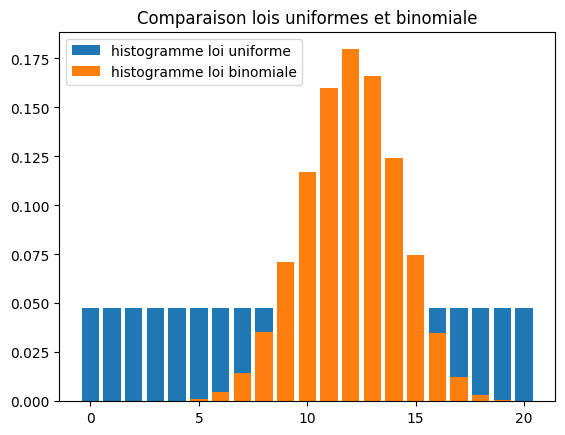

In [11]:
T=np.arange(0,21) 
X=stats.binom.pmf(T,20,0.6)
Y=stats.randint.pmf(T,0,21)
plt.bar(T,Y,label='histogramme loi uniforme')
plt.bar(T,X,label='histogramme loi binomiale')
plt.title('Comparaison lois uniformes et binomiale')
plt.legend()
plt.show()

Enfin, autre capacité utile pour les illustrations de convergence: savoir tracer une fonction en escalier (PAR EXEMPLE, une fonction de répartition empirique, à tout hasard): 

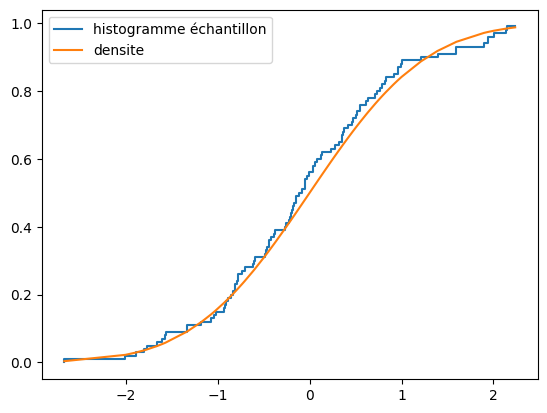

In [13]:
n=100
X=stats.norm.rvs(loc=0,scale=1, size=n)
X_tri=np.sort(X)
plt.plot(X_tri,np.arange(n)/n,drawstyle='steps-pre',label='histogramme échantillon') # ça, c'est vraiment LA commande magique à retenir !!!!!
plt.plot(X_tri,stats.norm.cdf(X_tri), label='densite')
plt.legend()
plt.show()